# Objetivo do trabalho
Uso da Resnet152 para detecção de cancer de intestino

### Download do LC25000 através do kaggle

In [ ]:
from google.colab import files
!pip install -q kaggle

In [ ]:
def upload_kaggle_dataset_in_colab():
    files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

def unzip_kaggle_dataset_in_colab():
    !kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images
    !unzip -q lung-and-colon-cancer-histopathological-images.zip

def unzip_support_functions_in_colab():
    !kaggle datasets download -d gabrielcruzvazsantos/colon-detection-support-functions
    !unzip -q colon-detection-support-functions.zip


def get_kaggle_dataset_in_colab():
    upload_kaggle_dataset_in_colab()
    unzip_kaggle_dataset_in_colab()
    unzip_support_functions_in_colab()

In [ ]:
get_kaggle_dataset_in_colab()

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
 99% 1.73G/1.76G [00:16<00:00, 227MB/s]
100% 1.76G/1.76G [00:16<00:00, 117MB/s]
Dataset URL: https://www.kaggle.com/datasets/gabrielcruzvazsantos/colon-detection-support-functions
License(s): unknown
  0% 0.00/4.55k [00:00<?, ?B/s]
100% 4.55k/4.55k [00:00<00:00, 22.5MB/s]


## Uso de código externo
Esse notebook foi preparado para utilizar código modular python externo que, para seu devido funcionamento, precisa ser feito o upload via

In [ ]:
from get_formatted_datasets import get_formatted_datasets
from get_dataloaders import get_dataloaders
from train_and_test_model import train_model, test_model


In [ ]:
import torch
import torchvision
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns


### Datasets e dataLoader

In [ ]:
df_train, df_validation, df_test = get_formatted_datasets()

100%|██████████| 10002/10002 [00:00<00:00, 23862.59it/s]


CSV salvo com sucesso em: nb_lc25000.csv


In [ ]:
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test, 64)

### Modelo e treinamento
- ResNet152
- Canais de entrada - imagem RGB: 3
- Saída - Problema de classificação binária: 2
- Taxa de aprendizado: 0.002
- Otimizador: Adamax
- β1 = 0.9, β2 = 0.999
- Weight Decay: 1e-4
- Batch size = 64

In [ ]:
in_channels = 3
output_features = 2
learning_rate = 1e-2
weight_decay = 1e-4

In [ ]:
model = torchvision.models.resnet152(num_classes=output_features)
model = model.to("cuda")

In [ ]:
optimizer = torch.optim.Adamax(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), eps=1e-08, weight_decay=weight_decay)

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer, 50, 50)

Epoch 1/50 | Train Loss: 0.3493 | Val Loss: 0.3966 | Sem melhora: 0/50
Epoch 2/50 | Train Loss: 0.0855 | Val Loss: 1.3259 | Sem melhora: 1/50
Epoch 3/50 | Train Loss: 0.0491 | Val Loss: 0.0341 | Sem melhora: 0/50
Epoch 4/50 | Train Loss: 0.0267 | Val Loss: 0.4285 | Sem melhora: 1/50
Epoch 5/50 | Train Loss: 0.0187 | Val Loss: 0.1599 | Sem melhora: 2/50
Epoch 6/50 | Train Loss: 0.0286 | Val Loss: 0.0059 | Sem melhora: 0/50
Epoch 7/50 | Train Loss: 0.0186 | Val Loss: 0.0423 | Sem melhora: 1/50
Epoch 8/50 | Train Loss: 0.0091 | Val Loss: 0.0089 | Sem melhora: 2/50
Epoch 9/50 | Train Loss: 0.0289 | Val Loss: 0.0564 | Sem melhora: 3/50
Epoch 10/50 | Train Loss: 0.0182 | Val Loss: 1.1416 | Sem melhora: 4/50
Epoch 11/50 | Train Loss: 0.0101 | Val Loss: 0.0526 | Sem melhora: 5/50
Epoch 12/50 | Train Loss: 0.0100 | Val Loss: 0.0136 | Sem melhora: 6/50
Epoch 13/50 | Train Loss: 0.0023 | Val Loss: 0.0048 | Sem melhora: 0/50
Epoch 14/50 | Train Loss: 0.0178 | Val Loss: 0.0051 | Sem melhora: 1/50
E

### Imprimindo resultados treinamento e validação

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'train_losses' is not defined

<Figure size 800x500 with 0 Axes>

### Testando modelo

In [ ]:
acc, precision, recall, f1, cm = test_model(best_model, "cuda", dataloader_test)

Acurácia: 0.9970
Precisão (weighted): 0.9970
Recall (weighted): 0.9970
F1-score (weighted): 0.9970
Matriz de Confusão:
[[995   5]
 [  1 999]]


In [ ]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │   0.997 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │   0.997 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │   0.997 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │   0.997 │
╘═════════════════════╧═════════╛


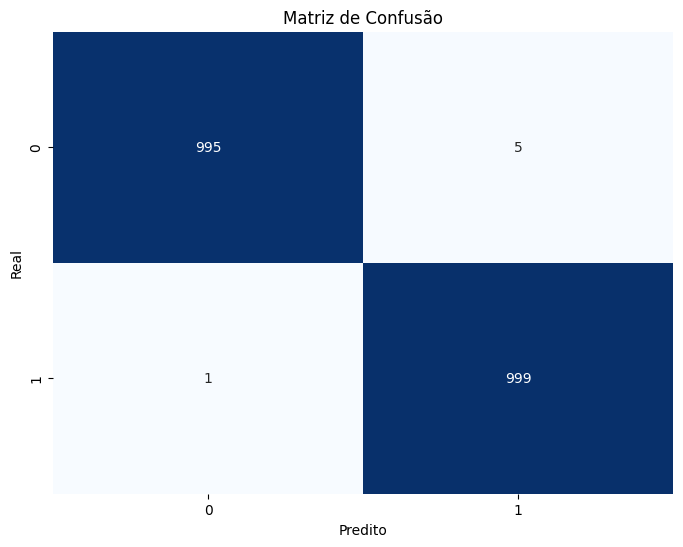

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

### Adição Dropout e DatasetMemory
Apesar de um bom resultado, os atuais valores estão variando muito. Por isso, aplicação de dropout com probabilidade de 0.5 será feita.
Além disso, será testado o uso do dataset que todas as imagens são carregadas diretamente na memória, ao invés de uma por um

In [ ]:
from get_formatted_datasets import get_formatted_datasets
from get_dataloaders import get_dataloaders
from train_and_test_model import train_model, test_model

In [ ]:
import torch
import torchvision
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns


In [ ]:
df_train, df_validation, df_test = get_formatted_datasets()

100%|██████████| 10002/10002 [00:00<00:00, 16475.37it/s]


CSV salvo com sucesso em: nb_lc25000.csv


In [ ]:
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test, 64, 2, True)

In [ ]:
in_channels = 3
output_features = 2
learning_rate = 1e-2
weight_decay = 1e-4
dropout = 0.5

In [ ]:
model = torchvision.models.resnet152(num_classes=output_features)
model.fc = torch.nn.Sequential(
  torch.nn.Dropout(dropout),
  torch.nn.Linear(model.fc.in_features, output_features)
)
model = model.to("cuda")

In [ ]:
optimizer = torch.optim.Adamax(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), eps=1e-08, weight_decay=weight_decay)

In [ ]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer, 50, 50)

Epoch 1/50 | Train Loss: 0.5287 | Val Loss: 0.1628
Epoch 2/50 | Train Loss: 0.1104 | Val Loss: 0.0280
Epoch 3/50 | Train Loss: 0.0530 | Val Loss: 0.0134
Epoch 4/50 | Train Loss: 0.0583 | Val Loss: 0.1118
Epoch 5/50 | Train Loss: 0.0279 | Val Loss: 0.0084
Epoch 6/50 | Train Loss: 0.0216 | Val Loss: 0.0875
Epoch 7/50 | Train Loss: 0.0205 | Val Loss: 0.5316
Epoch 8/50 | Train Loss: 0.0503 | Val Loss: 0.0238
Epoch 9/50 | Train Loss: 0.0285 | Val Loss: 0.0092
Epoch 10/50 | Train Loss: 0.0086 | Val Loss: 0.0123
Epoch 11/50 | Train Loss: 0.0291 | Val Loss: 8.3948
Epoch 12/50 | Train Loss: 0.0236 | Val Loss: 0.1786
Epoch 13/50 | Train Loss: 0.0215 | Val Loss: 0.0068
Epoch 14/50 | Train Loss: 0.0063 | Val Loss: 0.0097
Epoch 15/50 | Train Loss: 0.0107 | Val Loss: 3.8545
Epoch 16/50 | Train Loss: 0.0224 | Val Loss: 0.0558
Epoch 17/50 | Train Loss: 0.0122 | Val Loss: 0.4724
Epoch 18/50 | Train Loss: 0.0067 | Val Loss: 0.0061
Epoch 19/50 | Train Loss: 0.0065 | Val Loss: 0.0035
Epoch 20/50 | Train L

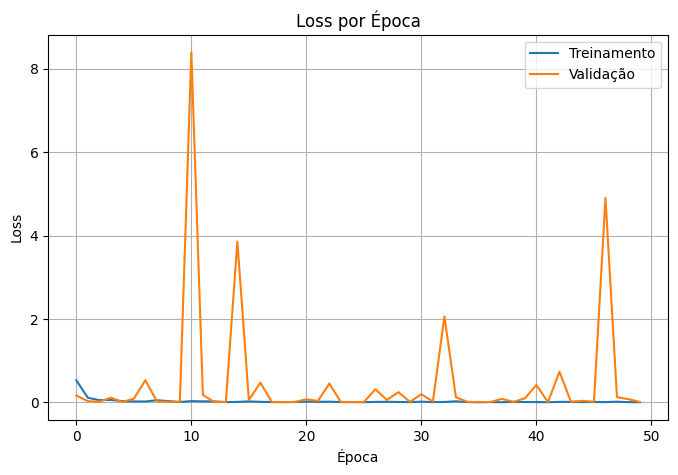

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Parecer final
Não foi possível fazer